In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

In [2]:
df = pd.read_csv('/content/breast_cancer_wisconsin_diagnostic_source.csv')

In [4]:
df.head()
df.shape
df.columns


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [7]:
df['diagnosis'].value_counts()

,count
diagnosis,
benign,357
malignant,212


In [9]:
print(df.columns.tolist())

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']


In [10]:
malignant = df[df['diagnosis'] == 'M']['mean radius']
benign = df[df['diagnosis'] == 'B']['mean radius']
print("Malignant cases:", len(malignant))
print("Benign cases:", len(benign))
print("Mean radius - Malignant:", malignant.mean())
print("Mean radius - Benign:", benign.mean())

Malignant cases: 0
Benign cases: 0
Mean radius - Malignant: nan
Mean radius - Benign: nan


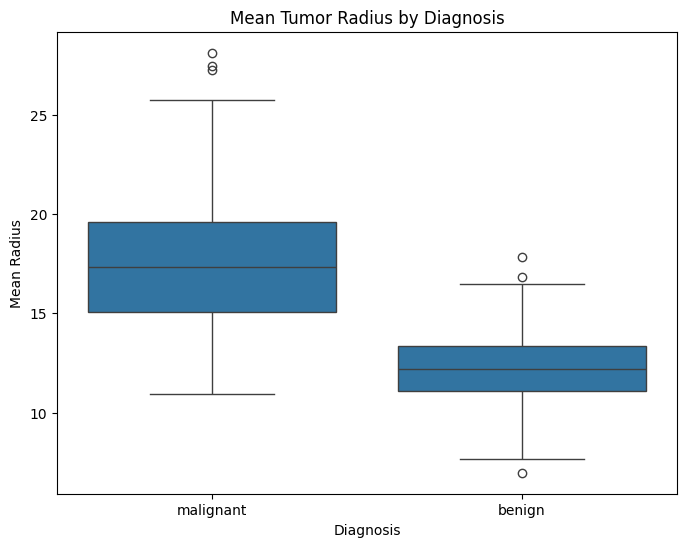

In [11]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='diagnosis', y='mean radius', data=df)

plt.title('Mean Tumor Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Radius')
plt.show()

In [15]:
print(df['mean radius'].isnull().sum())
print(df['mean radius'].dtype)

0
float64


In [16]:
print(df[['diagnosis', 'mean radius']].head(10))

   diagnosis  mean radius
0  malignant        17.99
1  malignant        20.57
2  malignant        19.69
3  malignant        11.42
4  malignant        20.29
5  malignant        12.45
6  malignant        18.25
7  malignant        13.71
8  malignant        13.00
9  malignant        12.46


In [25]:
print("Data type:", df['mean radius'].dtype)
print("Missing values:", df['mean radius'].isna().sum())

print("\nDiagnosis values:")
print(df['diagnosis'].value_counts(dropna=False))

print("\nTest dataframe:")
print(test_df.head())
print(test_df['mean radius'].describe())

malignant = test_df[test_df['diagnosis'] == 'malignant']['mean radius']

benign = test_df[test_df['diagnosis'] == 'benign']['mean radius']
print("Malignant cases:", len(malignant))
print("Benign cases:", len(benign))

print("Mean radius - Malignant:", malignant.mean())
print("Mean radius - Benign:", benign.mean())



Data type: float64
Missing values: 0

Diagnosis values:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Test dataframe:
   diagnosis  mean radius
0  malignant        17.99
1  malignant        20.57
2  malignant        19.69
3  malignant        11.42
4  malignant        20.29
count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64
Malignant cases: 212
Benign cases: 357
Mean radius - Malignant: 17.462830188679245
Mean radius - Benign: 12.146523809523808


In [26]:
print("Malignant missing:", malignant.isna().sum())
print("Benign missing:", benign.isna().sum())

print("Malignant infinite:", np.isinf(malignant).sum())
print("Benign infinite:", np.isinf(benign).sum())

print("Malignant dtype:", malignant.dtype)
print("Benign dtype:", benign.dtype)

Malignant missing: 0
Benign missing: 0
Malignant infinite: 0
Benign infinite: 0
Malignant dtype: float64
Benign dtype: float64


In [27]:
malignant_clean = malignant.replace([np.inf, -np.inf], np.nan).dropna()
benign_clean = benign.replace([np.inf, -np.inf], np.nan).dropna()

t_stat, p_value = ttest_ind(
    malignant_clean,
    benign_clean,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 22.208797758464527
P-value: 1.6844591259582747e-64


In [28]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean tumor radius.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean tumor radius.")

Reject the null hypothesis.
There is a statistically significant difference in mean tumor radius.


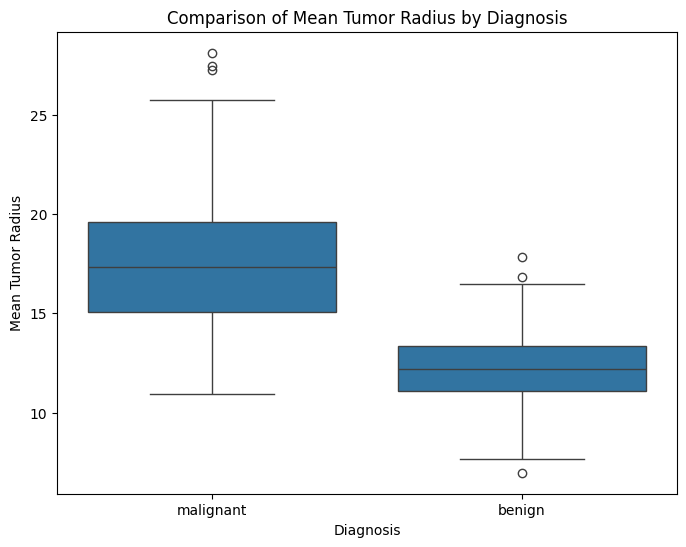

In [29]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='diagnosis',
    y='mean radius',
    data=test_df
)

plt.title('Comparison of Mean Tumor Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Tumor Radius')
plt.show()

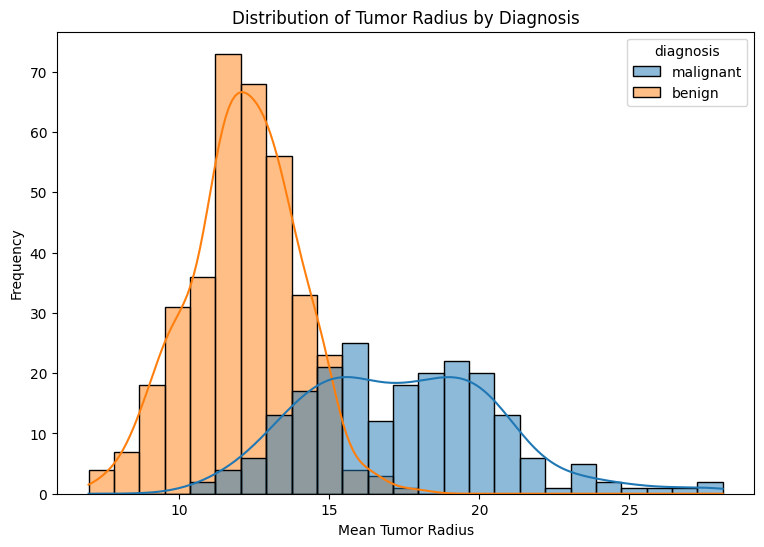

In [30]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=test_df,
    x='mean radius',
    hue='diagnosis',
    kde=True,
    bins=25
)

plt.title('Distribution of Tumor Radius by Diagnosis')
plt.xlabel('Mean Tumor Radius')
plt.ylabel('Frequency')
plt.show()

In [31]:
print("Mean radius - Malignant:", malignant_clean.mean())
print("Mean radius - Benign:", benign_clean.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean radius - Malignant: 17.462830188679245
Mean radius - Benign: 12.146523809523808
T-statistic: 22.208797758464527
P-value: 1.6844591259582747e-64


In [32]:
median_radius = test_df['mean radius'].median()

print("Median tumor radius:", median_radius)

Median tumor radius: 13.37


In [33]:
test_df['radius_category'] = np.where(
    test_df['mean radius'] <= median_radius,
    'Low Radius',
    'High Radius'
)
print(test_df[['mean radius', 'radius_category', 'diagnosis']].head())

   mean radius radius_category  diagnosis
0        17.99     High Radius  malignant
1        20.57     High Radius  malignant
2        19.69     High Radius  malignant
3        11.42      Low Radius  malignant
4        20.29     High Radius  malignant


In [34]:
contingency_table = pd.crosstab(
    test_df['radius_category'],
    test_df['diagnosis']
)

print(contingency_table)

diagnosis        benign  malignant
radius_category                   
High Radius          89        195
Low Radius          268         17


In [35]:
chi2, p_value_chi, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value_chi)
print("Degrees of freedom:", dof)

Chi-square statistic: 236.52797526117857
P-value: 2.247938676287646e-53
Degrees of freedom: 1


In [36]:
if p_value_chi < 0.05:
    print("Reject the null hypothesis.")
    print("There is a significant association between radius category and diagnosis.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant association between radius category and diagnosis.")

Reject the null hypothesis.
There is a significant association between radius category and diagnosis.


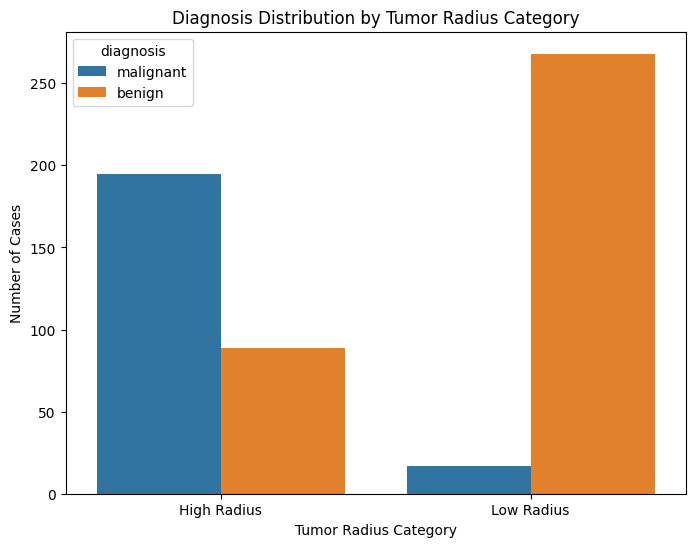

In [37]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=test_df,
    x='radius_category',
    hue='diagnosis'
)

plt.title('Diagnosis Distribution by Tumor Radius Category')
plt.xlabel('Tumor Radius Category')
plt.ylabel('Number of Cases')
plt.show()

In [42]:
anova_df = df[['diagnosis', 'mean radius', 'mean perimeter']].dropna()

In [43]:
anova_df['radius_group'] = pd.qcut(
    anova_df['mean radius'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

In [44]:
print(anova_df['radius_group'].value_counts())

radius_group
Small     191
Large     190
Medium    188
Name: count, dtype: int64


In [45]:
print(
    anova_df.groupby('radius_group', observed=True)['mean perimeter'].mean()
)

radius_group
Small      69.306859
Medium     86.687287
Large     119.976632
Name: mean perimeter, dtype: float64


In [46]:
small = anova_df[anova_df['radius_group'] == 'Small']['mean perimeter']
medium = anova_df[anova_df['radius_group'] == 'Medium']['mean perimeter']
large = anova_df[anova_df['radius_group'] == 'Large']['mean perimeter']

In [47]:
print("Small:", len(small))
print("Medium:", len(medium))
print("Large:", len(large))

Small: 191
Medium: 188
Large: 190


In [48]:
f_stat, p_value_anova = f_oneway(
    small,
    medium,
    large
)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 860.6004705050727
P-value: 2.3116771222939723e-172


In [49]:
if p_value_anova < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean perimeter among the radius groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean perimeter among the radius groups.")

Reject the null hypothesis.
There is a statistically significant difference in mean perimeter among the radius groups.


In [50]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=anova_df['mean perimeter'],
    groups=anova_df['radius_group'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
 Large Medium -33.2893   0.0 -36.2165 -30.3622   True
 Large  Small -50.6698   0.0 -53.5854 -47.7542   True
Medium  Small -17.3804   0.0 -20.3038 -14.4571   True
-----------------------------------------------------


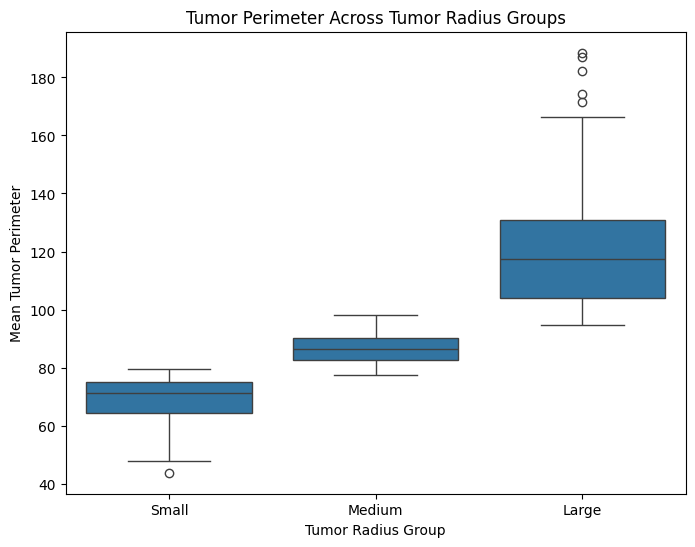

In [51]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=anova_df,
    x='radius_group',
    y='mean perimeter'
)

plt.title('Tumor Perimeter Across Tumor Radius Groups')
plt.xlabel('Tumor Radius Group')
plt.ylabel('Mean Tumor Perimeter')

plt.show()

In [52]:
# Difference between the two group means
mean_difference = malignant_clean.mean() - benign_clean.mean()

# Standard error
se = np.sqrt(
    malignant_clean.var(ddof=1) / len(malignant_clean) +
    benign_clean.var(ddof=1) / len(benign_clean)
)

# Welch-Satterthwaite degrees of freedom
df_welch = (
    (malignant_clean.var(ddof=1) / len(malignant_clean) +
     benign_clean.var(ddof=1) / len(benign_clean)) ** 2
    /
    (
        (malignant_clean.var(ddof=1) / len(malignant_clean)) ** 2 /
        (len(malignant_clean) - 1)
        +
        (benign_clean.var(ddof=1) / len(benign_clean)) ** 2 /
        (len(benign_clean) - 1)
    )
)

# Critical t-value
t_critical = stats.t.ppf(0.975, df_welch)

# Confidence interval
ci_lower = mean_difference - t_critical * se
ci_upper = mean_difference + t_critical * se

print("Mean Difference:", mean_difference)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Mean Difference: 5.316306379155437
95% Confidence Interval: (np.float64(4.845165154122919), np.float64(5.787447604187955))


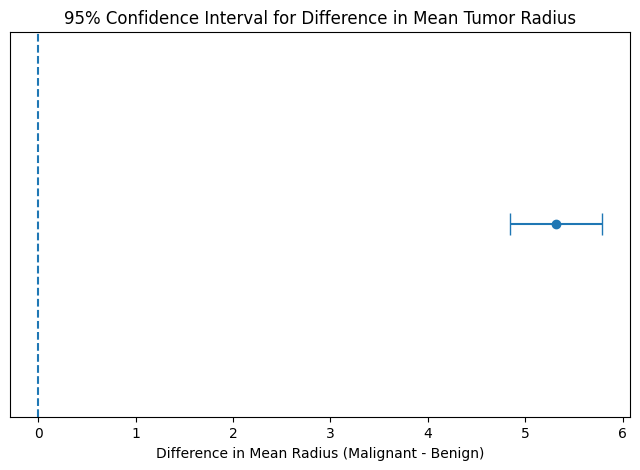

In [53]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=mean_difference,
    y=0,
    xerr=[[mean_difference - ci_lower],
          [ci_upper - mean_difference]],
    fmt='o',
    capsize=8
)

plt.axvline(0, linestyle='--')

plt.title('95% Confidence Interval for Difference in Mean Tumor Radius')
plt.xlabel('Difference in Mean Radius (Malignant - Benign)')
plt.yticks([])

plt.show()